# Ejection fraction agreement

Runs the trained model over the CAMUS test split, turns each patient's four
predicted contours into LV volumes with Simpson's biplane method of disks
(`volume.py`), and compares the resulting ejection fraction against the reference
EF stored in every patient's `Info_{view}.cfg`.

Dice does not answer the clinical question. EF is a ratio of two volume
estimates, each dominated by the widest discs near the mitral plane, so a model
can hold Dice ~0.93 on the cavity and still misplace a patient's EF by ten
points — or place them in the wrong category entirely.

**Three comparisons, not one.** The cfg EF is a clinical measurement, not this
computation applied to the reference contours, so running Simpson on the *expert*
contours already disagrees with it. Attributing that offset to the model would be
wrong, so the analysis separates:

| comparison | what it isolates |
| --- | --- |
| expert contours vs cfg EF | the method/reference floor — no model involved |
| model vs expert contours | segmentation error alone, same method both sides |
| model vs cfg EF | end-to-end clinical agreement, which contains both |

In [14]:
%load_ext autoreload
%autoreload 2

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D
from torch.utils.data import DataLoader

from camus_dataset import LABELS, CAMUSDataset
from model import build_unet, resolve_device
from volume import DISKS, LandmarkError, ejection_fraction, lv_volume_biplane

DATA_ROOT = Path.cwd().parent / "CAMUS_public"
RUN_DIR = Path("runs/unet_baseline/test2")
CHECKPOINT = RUN_DIR / "best.pt"
SPLIT = "test"

assert DATA_ROOT.is_dir(), f"CAMUS_public not found at {DATA_ROOT} - fix DATA_ROOT"
assert CHECKPOINT.is_file(), f"no checkpoint at {CHECKPOINT} - fix RUN_DIR"

plt.rcParams["figure.dpi"] = 110
DEVICE = resolve_device()
print(f"checkpoint  {CHECKPOINT}")
print(f"device      {DEVICE}   discs per volume: {DISKS}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
checkpoint  runs/unet_baseline/test2/best.pt
device      cuda   discs per volume: 20


## 1. Model and data

In [13]:
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
cfg = checkpoint["config"]

model = build_unet().to(DEVICE)
model.load_state_dict(checkpoint["model"])
model.eval()

image_size = (cfg["image_size"], cfg["image_size"])
test_ds = CAMUSDataset(DATA_ROOT, split=SPLIT, image_size=image_size)
test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=4)

print(f"epoch {checkpoint['epoch']}  ·  val_dice {checkpoint['val_dice']:.4f}")
print(test_ds)

epoch 21  ·  val_dice 0.9053
CAMUSDataset(split='test', patients=50, samples=200, views=('2CH', '4CH'), instants=('ED', 'ES'), image_size=(256, 256), normalize='unit')


## 2. One inference pass, measured on native geometry

The model runs at the resolution it was trained on, but the volumes are computed
after mapping the prediction back to the patient's native pixel grid.

That is not fussiness. CAMUS images are natively 0.308 × 0.308 mm — square — but
they are not square *images*, so resizing them to 256 × 256 stretches the axes by
different factors and leaves pixels like 0.66 × 0.80 mm. The disc measurement
rotates the mask to stand the long axis upright, and rotating a grid of
non-square pixels mixes the two spacings into every diameter. `volume.py` refuses
anisotropic spacing outright rather than quietly returning a plausible number.

Resampling itself is not the concern (nearest-neighbour resizing moves LV area by
0.006% on average across this split) — the pixel shape is.

In [3]:
# Same split at native resolution: the expert masks and the true pixel spacing.
native_ds = CAMUSDataset(DATA_ROOT, split=SPLIT, image_size=None)
native_index = {str(key): i for i, key in enumerate(native_ds.samples)}

cases = {}  # "patientXXXX_VIEW_INSTANT" -> everything needed downstream

with torch.inference_mode():
    for batch in test_loader:
        preds = model(batch["image"].to(DEVICE)).argmax(1)
        for i, key in enumerate(batch["key"]):
            native = native_ds[native_index[key]]
            # Nearest-exact keeps the prediction a label map; anything smoother
            # would invent fractional classes along the borders.
            pred_native = torch.nn.functional.interpolate(
                preds[i][None, None].float(),
                size=tuple(native["original_size"].tolist()),
                mode="nearest-exact",
            )[0, 0].long().cpu().numpy()

            cases[key] = {
                "pred": pred_native,
                "label": native["label"].numpy(),
                "spacing": tuple(native["spacing"].tolist()),
                "pred_small": preds[i].cpu().numpy(),      # 256x256, for the figures
                "label_small": batch["label"][i].numpy(),
                "image_small": batch["image"][i, 0].numpy(),
                "ref_ef": float(batch["ef"][i]),
                "quality": batch["image_quality"][i],
            }

patients = sorted({key.split("_")[0] for key in cases})
spacings = np.array([case["spacing"] for case in cases.values()])
print(f"{len(cases)} images  ·  {len(patients)} patients")
print(f"native spacing {spacings.min():.3f}-{spacings.max():.3f} mm/px "
      f"(square: {bool(np.allclose(spacings[:, 0], spacings[:, 1]))})")

200 images  ·  50 patients
native spacing 0.308-0.308 mm/px (square: True)


## 3. Volumes and EF per patient

Both sources go through exactly the same geometry, so the model-vs-expert
comparison later contains segmentation error and nothing else.

A `LandmarkError` means the cavity was empty or never touched the atrium, leaving
no mitral plane to measure from. Those patients are counted and reported rather
than dropped — a patient the pipeline cannot measure is a result.

In [4]:
def patient_volumes(patient, source):
    """(EDV, ESV) in mL for one patient from `source` masks ("pred" or "label")."""
    volumes = {}
    for instant in ("ED", "ES"):
        two, four = cases[f"{patient}_2CH_{instant}"], cases[f"{patient}_4CH_{instant}"]
        volumes[instant] = lv_volume_biplane(
            two[source], two["spacing"], four[source], four["spacing"]
        )
    return volumes["ED"], volumes["ES"]


rows, failures = [], []
for patient in patients:
    try:
        model_edv, model_esv = patient_volumes(patient, "pred")
        gt_edv, gt_esv = patient_volumes(patient, "label")
    except LandmarkError as error:
        failures.append((patient, str(error)))
        continue
    rows.append({
        "patient": patient,
        "model_edv": model_edv, "model_esv": model_esv,
        "model_ef": ejection_fraction(model_edv, model_esv),
        "gt_edv": gt_edv, "gt_esv": gt_esv,
        "gt_ef": ejection_fraction(gt_edv, gt_esv),
        "ref_ef": cases[f"{patient}_2CH_ED"]["ref_ef"],
        "quality": cases[f"{patient}_2CH_ED"]["quality"],
    })

column = lambda name: np.array([row[name] for row in rows])
model_ef, gt_ef, ref_ef = column("model_ef"), column("gt_ef"), column("ref_ef")

print(f"measured {len(rows)}/{len(patients)} patients"
      + (f"  ·  {len(failures)} failed: {failures}" if failures else "  ·  no failures"))
print(f"\nEDV  expert {column('gt_edv').mean():6.1f} mL   model {column('model_edv').mean():6.1f} mL")
print(f"ESV  expert {column('gt_esv').mean():6.1f} mL   model {column('model_esv').mean():6.1f} mL")
print(f"EF   expert {gt_ef.mean():6.1f} %    model {model_ef.mean():6.1f} %    "
      f"reference {ref_ef.mean():6.1f} %")
if (model_ef < 0).any():
    print(f"\nnegative model EF (ESV > EDV) for: "
          f"{[rows[i]['patient'] for i in np.flatnonzero(model_ef < 0)]}")

measured 50/50 patients  ·  no failures

EDV  expert   93.3 mL   model   90.1 mL
ESV  expert   47.0 mL   model   48.6 mL
EF   expert   51.9 %    model   46.8 %    reference   44.7 %

negative model EF (ESV > EDV) for: ['patient0273']


## 4. Agreement helpers

Bland–Altman plots the difference against the mean of the two measurements, which
is the right frame when neither is a gold standard: a correlation plot would hide
a constant offset, and this one puts it on the y-axis as the bias line. The dashed
lines are the 95% limits of agreement (bias ± 1.96 sd) — the interval that
matters clinically, because it is the range a single new patient's error can be
expected to fall in.

In [5]:
def agreement(a, b):
    """Bland-Altman statistics for paired measurements `a` and `b`."""
    diff = np.asarray(a) - np.asarray(b)
    bias, sd = float(diff.mean()), float(diff.std(ddof=1))
    return {
        "n": int(diff.size),
        "bias": bias,
        "sd": sd,
        "loa_low": bias - 1.96 * sd,
        "loa_high": bias + 1.96 * sd,
        "mae": float(np.abs(diff).mean()),
        "rmse": float(np.sqrt((diff ** 2).mean())),
        "corr": float(np.corrcoef(a, b)[0, 1]),
    }


def plot_agreement(axes, a, b, name_a, name_b, unit="EF (%)", color="#4a7fe8"):
    """Scatter-vs-identity on the left, Bland-Altman on the right."""
    stats = agreement(a, b)
    limits = [min(np.min(a), np.min(b)), max(np.max(a), np.max(b))]
    pad = 0.05 * (limits[1] - limits[0])
    limits = [limits[0] - pad, limits[1] + pad]

    axes[0].scatter(b, a, s=18, alpha=0.6, color=color)
    axes[0].plot(limits, limits, color="0.4", lw=1, ls="--")
    axes[0].set_xlim(limits); axes[0].set_ylim(limits)
    axes[0].set_xlabel(f"{name_b} {unit}"); axes[0].set_ylabel(f"{name_a} {unit}")
    axes[0].set_title(f"{name_a} vs {name_b}   r = {stats['corr']:.3f}", fontsize=9)
    axes[0].grid(alpha=0.25)

    mean, diff = (np.asarray(a) + np.asarray(b)) / 2, np.asarray(a) - np.asarray(b)
    axes[1].scatter(mean, diff, s=18, alpha=0.6, color=color)
    axes[1].axhline(0, color="0.4", lw=1, ls=":")
    axes[1].axhline(stats["bias"], color="#e8564a", lw=1.3,
                    label=f"bias {stats['bias']:+.2f}")
    for bound, tag in ((stats["loa_high"], "95% LoA"), (stats["loa_low"], None)):
        axes[1].axhline(bound, color="#e8564a", lw=1, ls="--", label=tag)
        axes[1].annotate(f"{bound:+.1f}", (0.99, bound), xycoords=("axes fraction", "data"),
                         ha="right", va="bottom", fontsize=7, color="#e8564a")
    axes[1].set_xlabel(f"mean of the two {unit}")
    axes[1].set_ylabel(f"{name_a} − {name_b}")
    axes[1].set_title(f"Bland–Altman   sd {stats['sd']:.2f}  MAE {stats['mae']:.2f}", fontsize=9)
    axes[1].legend(fontsize=7, loc="upper left"); axes[1].grid(alpha=0.25)
    return stats

## 5. The three EF comparisons

Read them top to bottom. The first row contains no model at all: whatever bias it
shows is the cost of deriving EF from two frames of contours by Simpson's rule
rather than however the clinical value was measured. Only the second row is the
model's own error.

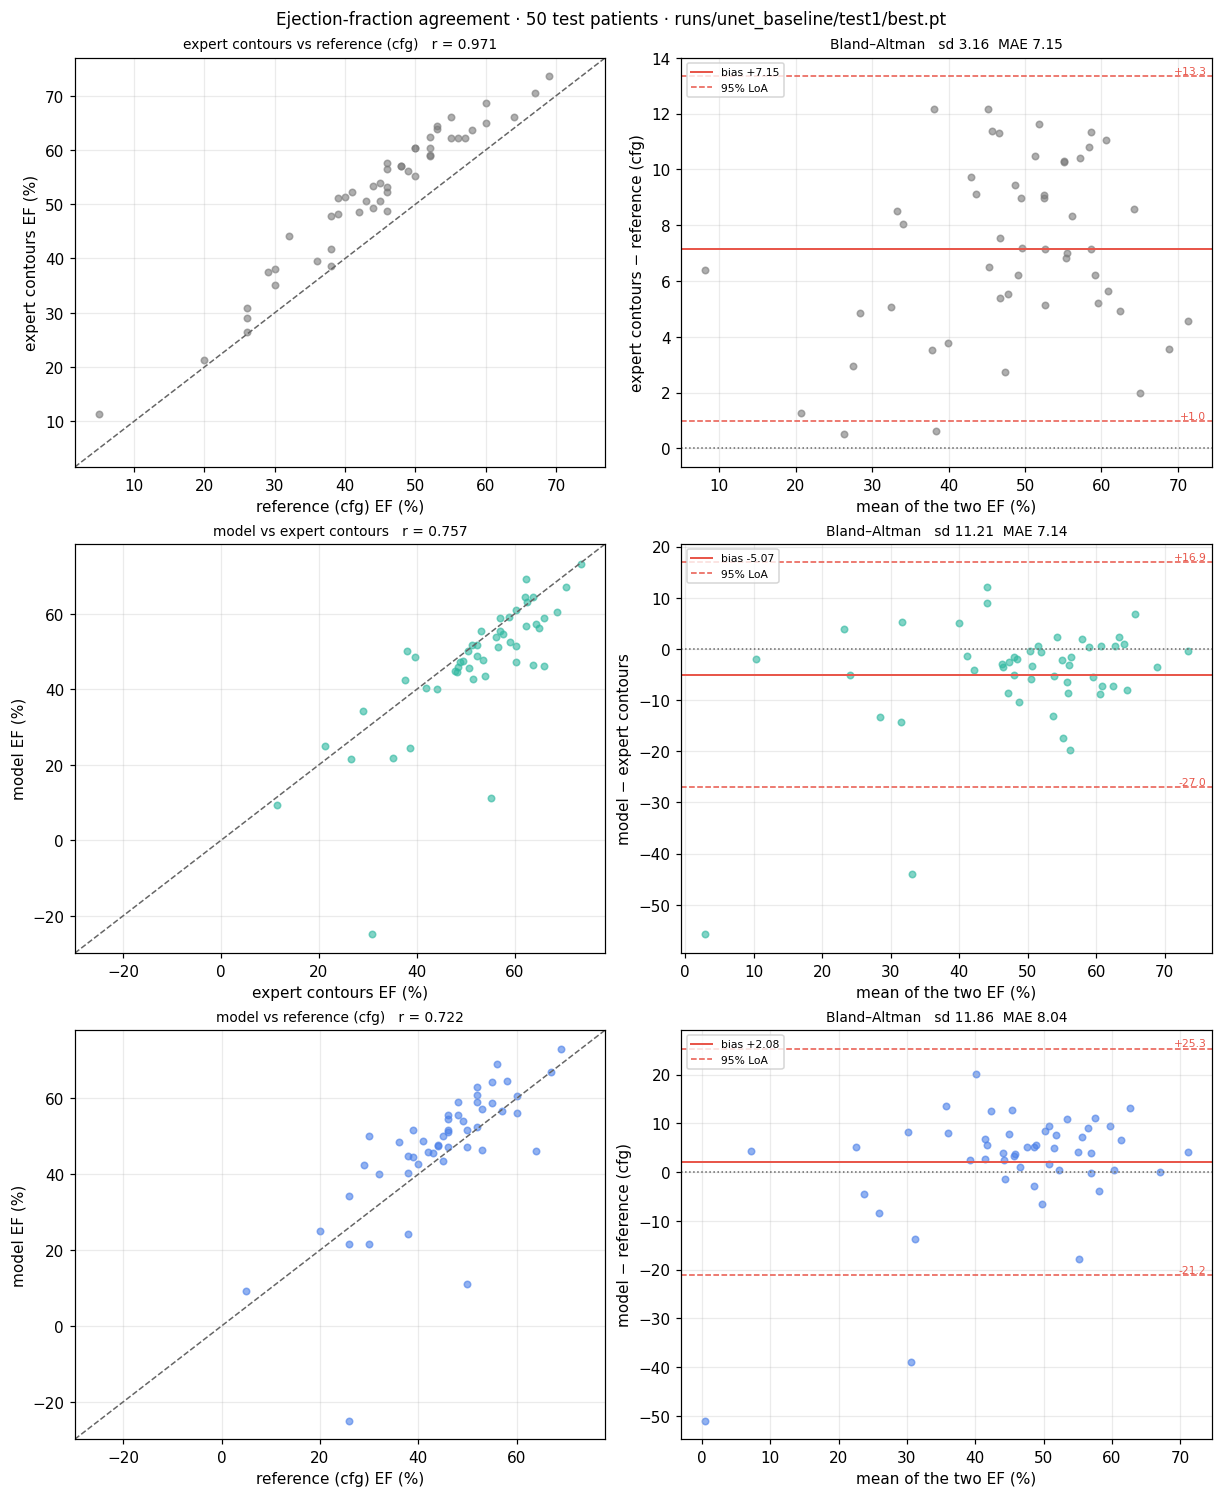

comparison                              bias     sd    MAE   RMSE      r   95% LoA
-------------------------------------------------------------------------------------------
expert contours vs reference (cfg)     +7.15   3.16   7.15   7.80  0.971   [+1.0, +13.3]
model vs expert contours               -5.07  11.21   7.14  12.20  0.757   [-27.0, +16.9]
model vs reference (cfg)               +2.08  11.86   8.04  11.92  0.722   [-21.2, +25.3]


In [6]:
comparisons = [
    ("expert contours", gt_ef, "reference (cfg)", ref_ef, "#7a7a7a"),
    ("model", model_ef, "expert contours", gt_ef, "#2fb8a0"),
    ("model", model_ef, "reference (cfg)", ref_ef, "#4a7fe8"),
]

fig, axes = plt.subplots(3, 2, figsize=(11, 13.5), layout="constrained")
ef_stats = {}
for row, (name_a, a, name_b, b, color) in zip(axes, comparisons):
    ef_stats[f"{name_a} vs {name_b}"] = plot_agreement(row, a, b, name_a, name_b, color=color)
fig.suptitle(f"Ejection-fraction agreement · {len(rows)} test patients · {CHECKPOINT}",
             fontsize=11)
plt.show()

width = max(len(k) for k in ef_stats) + 2
print(f"{'comparison':<{width}}{'bias':>8}{'sd':>7}{'MAE':>7}{'RMSE':>7}{'r':>7}   95% LoA")
print("-" * (width + 55))
for name, s in ef_stats.items():
    print(f"{name:<{width}}{s['bias']:>+8.2f}{s['sd']:>7.2f}{s['mae']:>7.2f}{s['rmse']:>7.2f}"
          f"{s['corr']:>7.3f}   [{s['loa_low']:+.1f}, {s['loa_high']:+.1f}]")

## 6. The volumes underneath

EF hides compensating errors — a model that shrinks EDV and ESV by the same
fraction reports the right EF from two wrong volumes. There is no reference
volume in the cfg (it stores EF only), so this compares against the expert
contours, which is the only volume ground truth available.

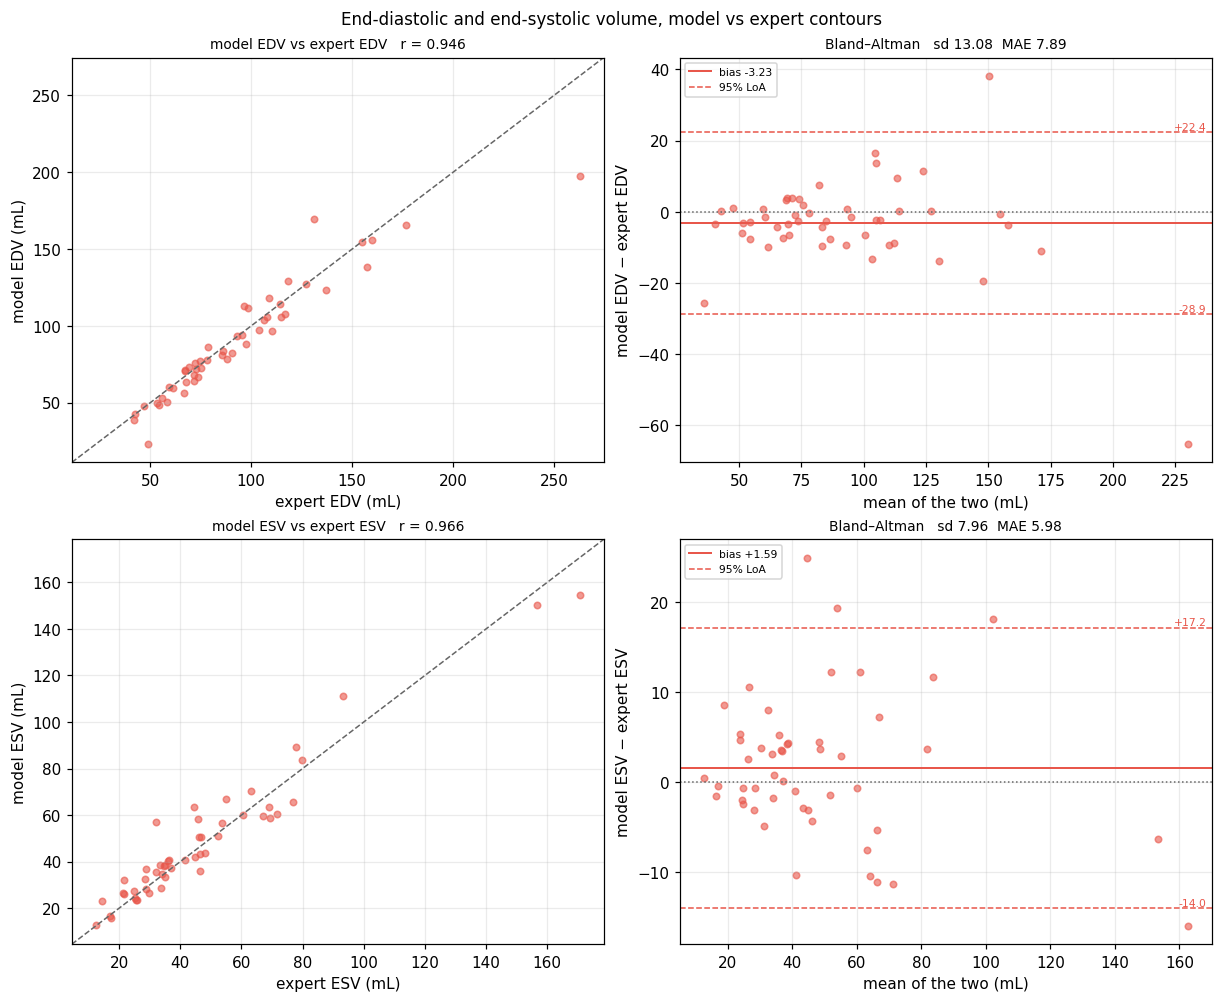

EDV  bias  -3.23 mL   sd 13.08   MAE  7.89 mL (8.5% of the expert mean)   r 0.946
ESV  bias  +1.59 mL   sd  7.96   MAE  5.98 mL (12.7% of the expert mean)   r 0.966


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), layout="constrained")
volume_stats = {}
for row, (tag, name) in zip(axes, (("edv", "EDV"), ("esv", "ESV"))):
    volume_stats[name] = plot_agreement(
        row, column(f"model_{tag}"), column(f"gt_{tag}"),
        f"model {name}", f"expert {name}", unit="(mL)", color="#e8564a",
    )
fig.suptitle("End-diastolic and end-systolic volume, model vs expert contours", fontsize=11)
plt.show()

for name, s in volume_stats.items():
    relative = s["mae"] / column(f"gt_{name.lower()}").mean()
    print(f"{name}  bias {s['bias']:+6.2f} mL   sd {s['sd']:5.2f}   MAE {s['mae']:5.2f} mL "
          f"({relative:.1%} of the expert mean)   r {s['corr']:.3f}")

## 7. Where EF goes wrong

EF error is driven by whichever frame the model got worse, and the two frames are
not equally forgiving: an ESV error moves EF more than the same relative error in
EDV, because ESV is the smaller volume. The table separates the two so a bad EF
can be traced to the frame that caused it.

In [8]:
ef_error = model_ef - gt_ef
worst = np.argsort(-np.abs(ef_error))[:8]

print(f"{'patient':<14}{'quality':<9}{'EF model':>9}{'EF expert':>10}{'EF ref':>8}"
      f"{'ΔEF':>8}{'ΔEDV %':>9}{'ΔESV %':>9}")
print("-" * 76)
for i in worst:
    row = rows[i]
    d_edv = (row["model_edv"] - row["gt_edv"]) / row["gt_edv"] * 100
    d_esv = (row["model_esv"] - row["gt_esv"]) / row["gt_esv"] * 100
    print(f"{row['patient']:<14}{row['quality']:<9}{row['model_ef']:>9.1f}{row['gt_ef']:>10.1f}"
          f"{row['ref_ef']:>8.0f}{ef_error[i]:>+8.1f}{d_edv:>+9.1f}{d_esv:>+9.1f}")

print(f"\n|ΔEF| by image quality (2CH ED view):")
for quality in ("Good", "Medium", "Poor"):
    mask = np.array([row["quality"] == quality for row in rows])
    if mask.any():
        print(f"  {quality:<7} n={mask.sum():<3} mean |ΔEF| {np.abs(ef_error[mask]).mean():5.2f}"
              f"   worst {np.abs(ef_error[mask]).max():5.1f}")

patient       quality   EF model EF expert  EF ref     ΔEF   ΔEDV %   ΔESV %
----------------------------------------------------------------------------
patient0273   Poor         -24.9      30.9      26   -55.8    -52.6    -14.4
patient0217   Medium        11.1      55.1      50   -44.0    -10.2    +77.9
patient0194   Good          46.2      66.0      64   -19.8     +0.7    +59.2
patient0239   Medium        46.5      63.8      53   -17.3     +1.1    +49.4
patient0047   Good          24.3      38.6      38   -14.3     +2.7    +26.6
patient0276   Poor          21.7      35.1      30   -13.4    -24.9     -9.4
patient0242   Medium        47.2      60.3      50   -13.1     -5.8    +25.3
patient0241   Medium        50.1      38.1      30   +12.1     -3.5    -22.3

|ΔEF| by image quality (2CH ED view):
  Good    n=19  mean |ΔEF|  4.99   worst  19.8
  Medium  n=21  mean |ΔEF|  7.30   worst  44.0
  Poor    n=10  mean |ΔEF| 10.89   worst  55.8


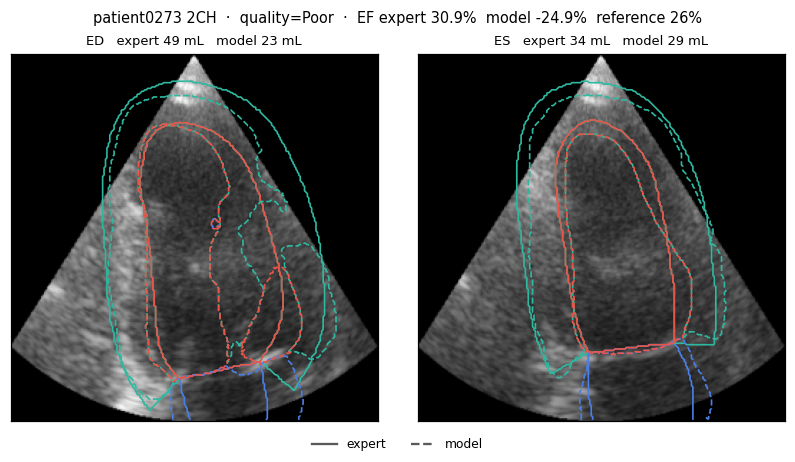

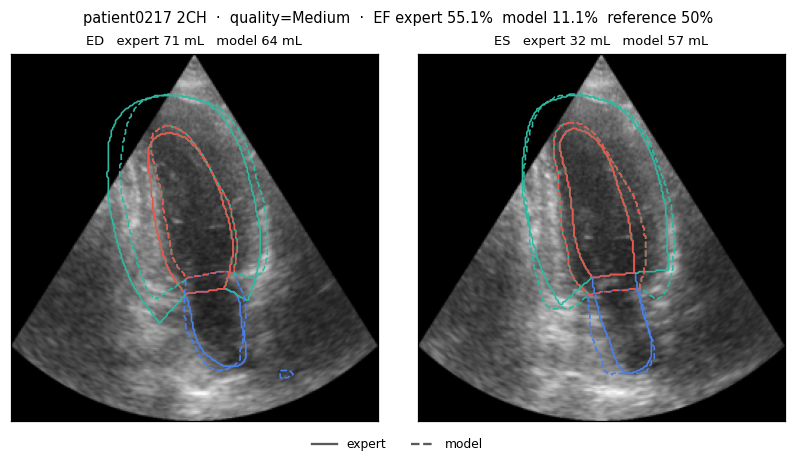

In [9]:
CLASS_COLORS = {1: "#e8564a", 2: "#2fb8a0", 3: "#4a7fe8"}


def contours(ax, label, linestyle):
    # Outermost first, so the endocardial border - the one the volume is measured
    # from - is drawn last and stays visible.
    for cls in sorted(CLASS_COLORS, reverse=True):
        mask = label == cls
        if mask.any():
            ax.contour(mask.astype(float), levels=[0.5], colors=[CLASS_COLORS[cls]],
                       linewidths=1.1, linestyles=linestyle)


def show_patient(patient, view="2CH"):
    """ED and ES for one patient: expert contours solid, model dashed."""
    row = next(r for r in rows if r["patient"] == patient)
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 4.1), layout="constrained")
    for ax, instant in zip(axes, ("ED", "ES")):
        case = cases[f"{patient}_{view}_{instant}"]
        ax.imshow(case["image_small"], cmap="gray")
        contours(ax, case["label_small"], "-")
        contours(ax, case["pred_small"], "--")
        volume_tag = "edv" if instant == "ED" else "esv"
        ax.set_title(f"{instant}   expert {row['gt_' + volume_tag]:.0f} mL   "
                     f"model {row['model_' + volume_tag]:.0f} mL", fontsize=8.5)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{patient} {view}  ·  quality={row['quality']}  ·  "
                 f"EF expert {row['gt_ef']:.1f}%  model {row['model_ef']:.1f}%  "
                 f"reference {row['ref_ef']:.0f}%", fontsize=9.5)
    fig.legend(handles=[Line2D([0], [0], color="0.35", lw=1.5, ls=ls, label=tag)
                        for ls, tag in (("-", "expert"), ("--", "model"))],
               loc="outside lower center", ncol=2, fontsize=8, frameon=False)
    return fig


for i in worst[:2]:
    show_patient(rows[i]["patient"])
plt.show()

## 8. Does the patient land in the right category?

A ±5 point EF error is harmless in the middle of the range and decisive at the
boundary. Guideline categories — reduced (< 40%), mid-range (40–54%), preserved
(≥ 55%) — are what actually gates treatment, so the last check is whether the
model puts each patient in the same box as the reference.

In [10]:
BOUNDARIES = [40, 55]
CATEGORIES = ["reduced (<40)", "mid-range (40-54)", "preserved (>=55)"]


def categorise(values):
    return np.digitize(values, BOUNDARIES)


def confusion(predicted, actual, title):
    matrix = np.zeros((len(CATEGORIES), len(CATEGORIES)), dtype=int)
    for p, a in zip(categorise(predicted), categorise(actual)):
        matrix[a, p] += 1
    agreement_rate = np.trace(matrix) / matrix.sum()

    width = max(len(c) for c in CATEGORIES) + 2
    print(f"{title}   agreement {agreement_rate:.1%} ({np.trace(matrix)}/{matrix.sum()})")
    print(f"{'actual \\ predicted':<{width}}" + "".join(f"{c:>20}" for c in CATEGORIES))
    for i, name in enumerate(CATEGORIES):
        print(f"{name:<{width}}" + "".join(f"{v:>20}" for v in matrix[i]))
    print()
    return matrix, float(agreement_rate)


categories = {
    "model vs reference": confusion(model_ef, ref_ef, "model vs reference (cfg) EF"),
    "model vs expert": confusion(model_ef, gt_ef, "model vs expert-contour EF"),
    "expert vs reference": confusion(gt_ef, ref_ef, "expert-contour vs reference (cfg) EF"),
}

model vs reference (cfg) EF   agreement 66.0% (33/50)
actual \ predicted        reduced (<40)   mid-range (40-54)    preserved (>=55)
reduced (<40)                         7                   8                   0
mid-range (40-54)                     1                  17                   7
preserved (>=55)                      0                   1                   9

model vs expert-contour EF   agreement 74.0% (37/50)
actual \ predicted        reduced (<40)   mid-range (40-54)    preserved (>=55)
reduced (<40)                         7                   3                   0
mid-range (40-54)                     0                  15                   1
preserved (>=55)                      1                   8                  15

expert-contour vs reference (cfg) EF   agreement 62.0% (31/50)
actual \ predicted        reduced (<40)   mid-range (40-54)    preserved (>=55)
reduced (<40)                        10                   5                   0
mid-range (40-54)           

## 9. Save

Written next to the checkpoint, so a run's clinical agreement stays with the
weights that produced it.

In [11]:
report_path = RUN_DIR / "ef_agreement.json"
report_path.write_text(json.dumps({
    "checkpoint": str(CHECKPOINT),
    "epoch": checkpoint["epoch"],
    "split": SPLIT,
    "disks": DISKS,
    "n_patients": len(rows),
    "failures": failures,
    "ef_agreement": ef_stats,
    "volume_agreement": volume_stats,
    "category_agreement": {name: {"matrix": matrix.tolist(), "rate": rate}
                           for name, (matrix, rate) in categories.items()},
    "per_patient": rows,
}, indent=2, default=str))
print(f"wrote {report_path}")

wrote runs/unet_baseline/test1/ef_agreement.json
